## ReAct Agent Architecture

### A general agent architecture :

1. ```act``` - let the model call specific tools
2. ```observe``` - pass the tool output back to the model
3. ```reason``` - let the model reason about the tool output to decide what to do next (e.g call another tool or just respond directly)

In [1]:
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper

In [2]:
api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=500)
arxiv = ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv.name)

arxiv


In [3]:
arxiv.invoke("Attention is All you Need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi'

In [5]:
api_wrapper_wiki = WikipediaAPIWrapper(top_k_results=1, doc_content_chars_max=500)
wiki = WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
print(wiki.name)

wikipedia


In [6]:
wiki.invoke("What is Deep Learning?")

'Page: Deep learning\nSummary: In machine learning, deep learning focuses on utilizing multilayered neural networks to perform tasks such as classification, regression, and representation learning. The field takes inspiration from biological neuroscience and revolves around stacking artificial neurons into layers and "training" them to process data. The adjective "deep" refers to the use of multiple layers (ranging from three to several hundred or thousands) in the network. Methods used can be sup'

In [9]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"] = "True"
os.environ["LANGCHAIN_PROJECT"] = "ReAct-Agent"


In [10]:
### Custom Function

def multiply(a:int, b:int)-> int:
    """Multiple a and b.
    
    Args:
        a: first int
        b: second int
    """
    return a * b

def add(a:int, b:int)-> int:
    """Adds a and b.
    
    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a:int, b:int)-> int:
    """Divides a and b.
    
    Args:
        a: first int
        b: second int
    """
    return a / b

tools = [arxiv, wiki, add, multiply, divide]

In [11]:
### Tavily Search Tool
from langchain_community.tools.tavily_search import TavilySearchResults
tavily = TavilySearchResults()

C:\Users\Karan\AppData\Local\Temp\ipykernel_37612\637379855.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


In [12]:
tavily.invoke("Provide me latest news about Indian cricket match")

[{'title': 'India Cricket Team News',
  'url': 'https://www.newsnow.co.uk/h/Sport/Cricket/India',
  'content': "NewsNow\n\n# India Cricket Team  Share\n\nShare\n\n## Latest\n\n#### About our India Cricket Team News\n\nLatest on the Indian National Cricket Team: breaking news, match results, player updates, fixtures, and in-depth analysis on Team India.\n\nFollow the Men in Blue on their quest for world domination. Get up-to-the-minute news on the Indian National Cricket Team, including match scores, series analysis, player performances, and upcoming fixtures. [...] NewsNow's Indian Cricket Team feed is your ultimate source for everything Team India. Whether you're a die-hard fan or simply love the game, get the latest news, analysis, and exclusive content.\n\n#### NewsNow\n\n#### Our Sites\n\n#### Work with us\n\n#### Legal\n\nNewsNow\n\n© Copyright 1997 - 2025 NewsNow Publishing\nLimited. All rights reserved. [...] Go beyond the headlines with expert insights into team strategies, pla

In [20]:
### Combine all tools in the list

tools = [arxiv, wiki, add, multiply, divide, tavily]

In [21]:
### Initialize LLM model

from langchain_groq import ChatGroq
llm= ChatGroq(model="qwen/qwen3-32b")
llm_with_tools = llm.bind_tools(tools)

In [24]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage
llm_with_tools.invoke([HumanMessage(content=f"Latest Indian Cricket news")])

AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking for the latest news about Indian Cricket. Let me think about the tools I have available. There\'s the Tavily Search Results JSON function which is good for current events. Since cricket news can be quite recent, using a search engine that provides up-to-date information would be best. The Wikipedia and Arxiv functions might not have the most current data. The add, multiply, and divide functions are obviously not relevant here. So, I should use the Tavily Search Results JSON with the query "Latest Indian Cricket news" to fetch the most recent and accurate information.\n', 'tool_calls': [{'id': 'p65kk41cw', 'function': {'arguments': '{"query":"Latest Indian Cricket news"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 152, 'prompt_tokens': 635, 'total_tokens': 787, 'completion_time': 0.304609754, 'completion_tokens_details': {'re

In [25]:
llm_with_tools.invoke([HumanMessage(content=f"Latest news of AI")]).tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'Latest news of AI'},
  'id': 'qdqdvseca',
  'type': 'tool_call'}]

In [26]:
## State Schema

from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages
class State(TypedDict):
    messages:Annotated[list[AnyMessage], add_messages]

In [27]:
#### Entire Chatbot with LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

#Build Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

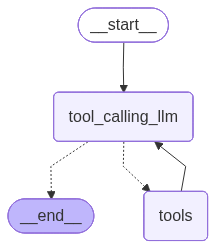

In [28]:
graph = builder.compile()

## View the graph

display(Image(graph.get_graph().draw_mermaid_png()))

In [32]:
messages = graph.invoke({"messages": HumanMessage(content="Latest cricket news about India. And add 8 to 22 then multiply by 5")})
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

Latest cricket news about India. And add 8 to 22 then multiply by 5
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (bd50bpz35)
 Call ID: bd50bpz35
  Args:
    query: Latest cricket news about India
  add (shfbrvcyh)
 Call ID: shfbrvcyh
  Args:
    a: 8
    b: 22
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "India Men's Cricket Team News | BCCI.tv", "url": "https://www.bcci.tv/international/men/news", "content": "### Board of Control for Cricket in India (BCCI) invites Quotations for 3D Signage Production and Management Services\n\n28th Nov, 2025\n\n### India’s U19 Squad for ACC Men’s U19 Asia Cup announced\n\n28th Nov, 2025\n\n### India’s squad for IDFC First Bank ODI series against South Africa announced\n\n23rd Nov, 2025\n\n# Latest News\n\nAxar Pate

## Agent Memory

Agent with Memory

In [33]:
messages = graph.invoke({"messages": HumanMessage(content="What is 7 + 71")})
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is 7 + 71
================================== Ai Message ==================================
Tool Calls:
  add (y8n6gg7qr)
 Call ID: y8n6gg7qr
  Args:
    a: 7
    b: 71
================================= Tool Message =================================
Name: add

78
================================== Ai Message ==================================

The sum of 7 and 71 is **78**.


In [34]:
messages = [HumanMessage(content=('Divide that by 5'))]

messages = graph.invoke({"messages": messages})
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

Divide that by 5
================================== Ai Message ==================================

To perform the division, I need to know the specific number you want divided by 5. Could you clarify what value you're referring to?


#### MemorySaver

LangGraph can use a checkpointer to automatically save the graph state after each step.

This built-in persistence layer gives us memory, allowing LangGraph to pick up from the last state update.

One of the easiest checkpointers to use is the MemorySaver, an in-memory key-value store for Graph state.

All we need to do is simply compile the graph with a checkpointer, and our graph has memory!

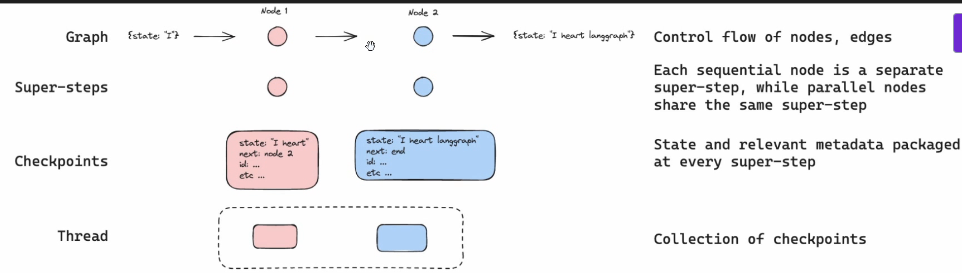

In [35]:
#### Entire Chatbot with LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

#Build Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

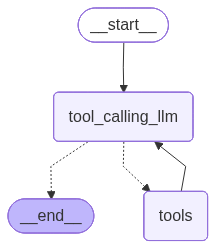

In [38]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()
graph_memory = builder.compile(checkpointer=memory)

#view
display(Image(graph_memory.get_graph().draw_mermaid_png()))

In [40]:
## Specify the thread

config = {"configurable":{"thread_id":"1"}}

#specify an input
messages = [HumanMessage(content="Add 13 and 14.")]
messages = graph_memory.invoke({"messages":messages}, config=config)
for m in messages["messages"]:
    m.pretty_print()


================================ Human Message =================================

Add 13 and 14.
================================== Ai Message ==================================
Tool Calls:
  add (6r4ydqtk3)
 Call ID: 6r4ydqtk3
  Args:
    a: 13
    b: 14
================================= Tool Message =================================
Name: add

27
================================== Ai Message ==================================

The sum of 13 and 14 is **27**.


In [41]:
messages = [HumanMessage(content="Add that number to 23")]
messages = graph_memory.invoke({"messages":messages}, config=config)
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

Add 13 and 14.
================================== Ai Message ==================================
Tool Calls:
  add (6r4ydqtk3)
 Call ID: 6r4ydqtk3
  Args:
    a: 13
    b: 14
================================= Tool Message =================================
Name: add

27
================================== Ai Message ==================================

The sum of 13 and 14 is **27**.
================================ Human Message =================================

Add that number to 23
================================== Ai Message ==================================
Tool Calls:
  add (dk93fte0w)
 Call ID: dk93fte0w
  Args:
    a: 27
    b: 23
================================= Tool Message =================================
Name: add

50
================================== Ai Message ==================================

The result of adding 27 and 23 is **50**.


In [43]:
messages = [HumanMessage(content="then divide it by 10")]
messages = graph_memory.invoke({"messages":messages}, config=config)
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

Add 13 and 14.
================================== Ai Message ==================================
Tool Calls:
  add (6r4ydqtk3)
 Call ID: 6r4ydqtk3
  Args:
    a: 13
    b: 14
================================= Tool Message =================================
Name: add

27
================================== Ai Message ==================================

The sum of 13 and 14 is **27**.
================================ Human Message =================================

Add that number to 23
================================== Ai Message ==================================
Tool Calls:
  add (dk93fte0w)
 Call ID: dk93fte0w
  Args:
    a: 27
    b: 23
================================= Tool Message =================================
Name: add

50
================================== Ai Message ==================================

The result of adding 27 and 23 is **50**.
================================ Human Message ======